In [10]:
import sys
sys.path.append('..')  # so `src` is importable from notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_and_validate, get_class_distribution

# Using the validated loader (not a raw pd.read_csv) so any schema
# issue surfaces here, at cell 1, rather than mid-analysis.
df = load_and_validate()
df.shape

(284807, 31)

In [11]:
dist = get_class_distribution(df)
print(dist)

fraud_count = df['Class'].sum()
total = len(df)
print(f"\nFraud cases: {fraud_count} / {total} ({fraud_count/total:.4%})")

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

Fraud cases: 492 / 284807 (0.1727%)


/var/folders/05/6xfvtbr91rv8mcsm5sxsxv840000gn/T/ipykernel_20436/967052375.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Not Fraud (0)', 'Fraud (1)'])


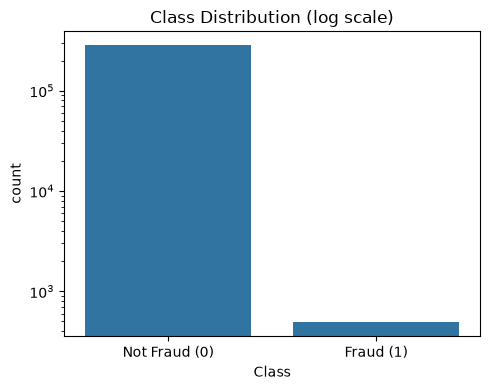

In [12]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x='Class', ax=ax)
ax.set_yscale('log')  # log scale is necessary here — on a linear
                       # scale the fraud bar is visually invisible
ax.set_title('Class Distribution (log scale)')
ax.set_xticklabels(['Not Fraud (0)', 'Fraud (1)'])
plt.tight_layout()
plt.show()